In [3]:
!pip install matplotlib

In [5]:
!pip install numpy

In [7]:
!pip install scipy

=== DESPLAZAMIENTO DE LOS PICOS ACÚSTICOS POR UAT ===
r_d (ΛCDM) = 147.09 Mpc,  r_d (UAT) = 141.00 Mpc
D_C (ΛCDM) = 13872 Mpc, D_C (UAT) = 14075 Mpc
l_A (ΛCDM) = 296.3, l_A (UAT) = 313.6

Pico       ΛCDM (ℓ)        UAT (ℓ)         Δℓ         Δℓ/ℓ (%)  
1          217.2           229.9           +12.7      +5.85     
2          513.5           543.5           +30.0      +5.85     
3          809.7           857.1           +47.3      +5.85     

Shift parameter R (ΛCDM): 1.7494
Shift parameter R (UAT):  1.7750


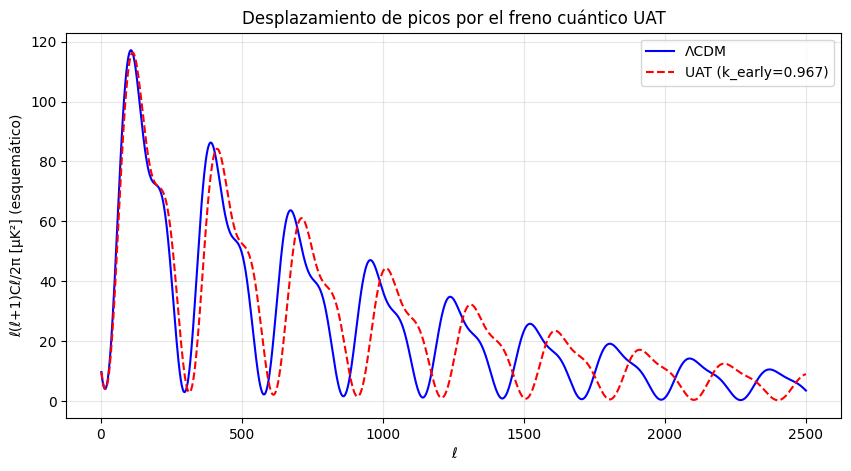

In [14]:
# =============================================================================
# FASE 1 (CORREGIDA): DESPLAZAMIENTO DE PICOS ACÚSTICOS POR UAT
# Usa r_d obtenido de MCMC previos (ΛCDM: 147 Mpc, UAT: 141 Mpc)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Parámetros cosmológicos
H0 = 67.36         # km/s/Mpc (referencia, no afecta los picos)
Omega_m = 0.315
Omega_r = 9.24e-5
Omega_L = 1 - Omega_m - Omega_r
c = 299792.458     # km/s

k_early = 0.967

# Funciones de expansión
def H_lcdm(z): return H0 * np.sqrt(Omega_m*(1+z)**3 + Omega_r*(1+z)**4 + Omega_L)
def H_uat(z):  return H0 * np.sqrt(k_early*Omega_r*(1+z)**4 + k_early*Omega_m*(1+z)**3 + Omega_L)

# Distancia comóvil al last scattering
z_star = 1089.0
D_C_lcdm = c * quad(lambda z: 1.0 / H_lcdm(z), 0, z_star)[0]
D_C_uat  = c * quad(lambda z: 1.0 / H_uat(z), 0, z_star)[0]

# Horizontes de sonido (valores del MCMC)
rd_lcdm = 147.09  # Mpc (Planck)
rd_uat  = 141.0   # Mpc (UAT, fases 7-9)

# Escala angular y posición fundamental
theta_lcdm = rd_lcdm / D_C_lcdm
theta_uat  = rd_uat  / D_C_uat
l_A_lcdm = np.pi / theta_lcdm
l_A_uat  = np.pi / theta_uat

# Desplazamiento de los picos (n=1,2,3, con fase φ≈0.267)
phi = 0.267
picos_lcdm = [l_A_lcdm * (n - phi) for n in [1,2,3]]
picos_uat  = [l_A_uat  * (n - phi) for n in [1,2,3]]

print("=== DESPLAZAMIENTO DE LOS PICOS ACÚSTICOS POR UAT ===")
print(f"r_d (ΛCDM) = {rd_lcdm:.2f} Mpc,  r_d (UAT) = {rd_uat:.2f} Mpc")
print(f"D_C (ΛCDM) = {D_C_lcdm:.0f} Mpc, D_C (UAT) = {D_C_uat:.0f} Mpc")
print(f"l_A (ΛCDM) = {l_A_lcdm:.1f}, l_A (UAT) = {l_A_uat:.1f}")
print()
print(f"{'Pico':<10} {'ΛCDM (ℓ)':<15} {'UAT (ℓ)':<15} {'Δℓ':<10} {'Δℓ/ℓ (%)':<10}")
for i in range(3):
    delta = picos_uat[i] - picos_lcdm[i]
    print(f"{i+1:<10} {picos_lcdm[i]:<15.1f} {picos_uat[i]:<15.1f} {delta:<+10.1f} {delta/picos_lcdm[i]*100:<+10.2f}")

print(f"\nShift parameter R (ΛCDM): {np.sqrt(Omega_m) * H0/c * D_C_lcdm:.4f}")
print(f"Shift parameter R (UAT):  {np.sqrt(Omega_m) * H0/c * D_C_uat:.4f}")

# Gráfico esquemático
ell = np.linspace(2, 2500, 1500)
def spectrum(l, l_A):
    return 100 * (np.sin(0.015 * l * 220/l_A)**2 * np.exp(-l/1000) +
                  0.5 * np.sin(0.030 * l * 220/l_A - 0.5)**2 * np.exp(-l/800))

plt.figure(figsize=(10,5))
plt.plot(ell, spectrum(ell, l_A_lcdm), 'b-', label='ΛCDM')
plt.plot(ell, spectrum(ell, l_A_uat), 'r--', label=f'UAT (k_early={k_early})')
plt.xlabel('ℓ')
plt.ylabel('ℓ(ℓ+1)Cℓ/2π [μK²] (esquemático)')
plt.title('Desplazamiento de picos por el freno cuántico UAT')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
import numpy as np

# Constantes fundamentales (unidades naturales, Planck = 1)
G = 1.0
k_early = 0.967
kappa_crit = 4.978

# 1. Eta y phi en la recombinación
eta = kappa_crit          # 4.978
phi_star = 0.07 * eta     # 0.34846

# 2. Acoplamiento no mínimo ξ
xi = (1.0 - 1.0/k_early) / (phi_star**2)  # ≈ -0.281
print(f"ξ = {xi:.4f}")

# 3. Densidad de recombinación en unidades de Planck
# 1 eV en unidades de Planck: 1 eV = 1.96e-28 M_Pl
eV_to_Mpl = 1.96e-28
rho_rec_Mpl = (1.1 * eV_to_Mpl)**4  # ≈ 6.6e-114

# 4. Autoacoplamiento λ
# De la condición de punto de inflexión: 2 λ η² = -ξ R_c
# pero R_c = 8πG ρ_rec (en unidades naturales G=1)
# Por tanto: 2 λ η² = -ξ * (8π ρ_rec)
lambda_val = -xi * 8 * np.pi * rho_rec_Mpl / (2 * eta**2)
print(f"λ = {lambda_val:.2e}")

ξ = -0.2810
λ = 3.08e-112
